# Data Preprocessing

In [1]:
# Import required liberaries
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# optionals
import warnings as w
w.filterwarnings("ignore")

# For Modelling
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("datasets/Steel_industry_data.csv")

In [3]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
# Display the first few rows, data info, and basic statistics
display("First few rows:", df.head())
print("\n")
display("Last few rows:", df.tail())
print("\n")
display("Summary Statistics:", df.describe())
print("\nData Info:\n")
print(df.info())

'First few rows:'

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


'Last few rows:'

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load
35039,31/12/2018 00:00,3.67,3.02,0.07,0.0,77.22,99.98,0,Weekday,Monday,Light_Load


'Summary Statistics:'

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000



Data Info:

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6)

## Handling Data types of features

In [5]:
df.dtypes

date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object

In [6]:
df.date.head()

0    01/01/2018 00:15
1    01/01/2018 00:30
2    01/01/2018 00:45
3    01/01/2018 01:00
4    01/01/2018 01:15
Name: date, dtype: str

In [7]:
df["date"] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')
df["date"]

0       2018-01-01 00:15:00
1       2018-01-01 00:30:00
2       2018-01-01 00:45:00
3       2018-01-01 01:00:00
4       2018-01-01 01:15:00
                ...        
35035   2018-12-31 23:00:00
35036   2018-12-31 23:15:00
35037   2018-12-31 23:30:00
35038   2018-12-31 23:45:00
35039   2018-12-31 00:00:00
Name: date, Length: 35040, dtype: datetime64[us]

## Handling Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

## Handling Missing Values

In [9]:
df.isna().sum().to_frame()

,0
date,0
Usage_kWh,0
Lagging_Current_Reactive.Power_kVarh,0
Leading_Current_Reactive_Power_kVarh,0
CO2(tCO2),0
Lagging_Current_Power_Factor,0
Leading_Current_Power_Factor,0
NSM,0
WeekStatus,0
Day_of_week,0


## Outlier Detection

In [10]:
from typing import Optional, Any

def outlier(df: pd.DataFrame, col: str):
    Q1, Q3 = np.percentile(df[col], [25, 75])
    IQR = Q3 - Q1
    minimum = Q1 - 1.5 * IQR
    maximum = Q3 + 1.5 * IQR
    return minimum, maximum

def outlier_plot(df, feature, min_val, max_val, ax):

    is_outlier = (df[feature] < min_val) | (df[feature] > max_val)

    sns.stripplot(
        y=df[feature],
        hue=is_outlier,
        palette={False: "skyblue", True: "orange"},
        ax=ax, 
        color="skyblue", 
        alpha=0.6,
        jitter=0.25,
        legend=False
    )

    ax.axhline(min_val, color="red", linestyle="--", label="Lower bound")
    ax.axhline(max_val, color="red", linestyle="--", label="Upper bound")

    outlier_df = df[is_outlier][feature]
    ax.scatter([], [], color="orange",label="Outliers")
    ax.set_title(f"{feature} with custom bounds")
    ax.legend(loc="upper right")

def outlier_detection(
    df: pd.DataFrame,
    features: Optional[list] = None
):
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
    
    df_features = set(df.columns)
    if features is not None:
        if set(features).issubset(df_features):

            # Grid formula
            N, C = len(features), 3

            rows = (N + C - 1) // C
            _, ax = plt.subplots(rows, C, figsize=(C * 4, 4 * rows))

            ax = np.array(ax).flatten()

            if len(features) == 1:
                ax = [ax]

            for i, feature in enumerate(features):
                min_val, max_val = outlier(df, feature)
                outlier_plot(df, feature, min_val, max_val, ax[i])

            plt.tight_layout()
            plt.show()

        else:
            raise ValueError(f"These features are not in the 'features' parameter: {set(features) - df_features}")
    else:
        # Grid formula
        N, C = len(features), 3
        rows = (N + C - 1) // C
        _, ax = plt.subplots(rows, C, figsize=(C * 4, 4 * rows))
        ax = np.array(ax).flatten()
        if len(df_features) == 1:
            ax = [ax]
        for i, feature in enumerate(df_features):
            min_val, max_val = outlier(df, feature)
            outlier_plot(df, feature, min_val, max_val, ax[i])
        plt.tight_layout()
        plt.show

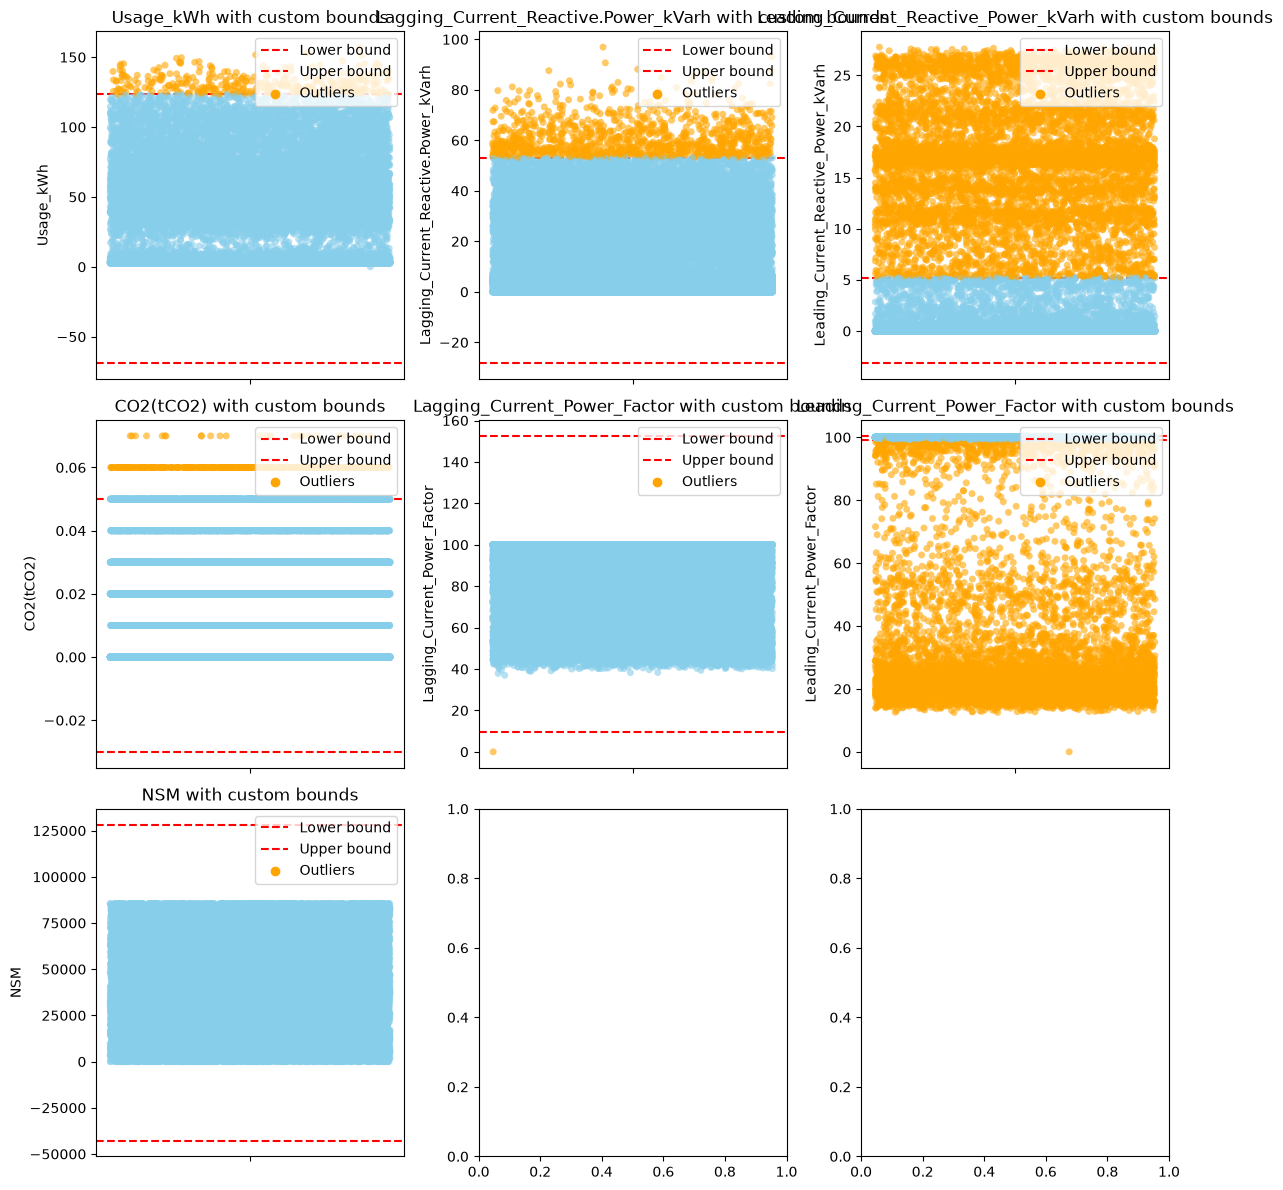

In [11]:
outlier_detection(df)

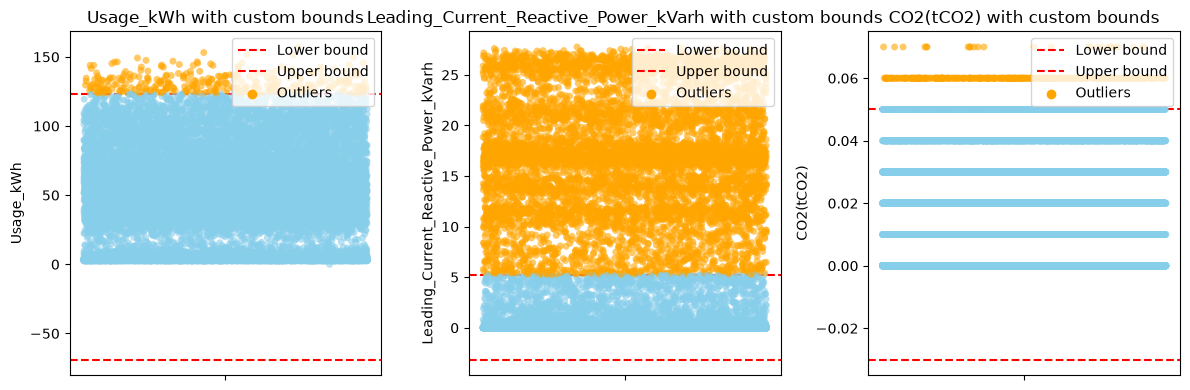

In [12]:
outlier_detection(df, ['Usage_kWh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)'])

## Handling floating point issues 

In [13]:
df.rename(columns={
    "Lagging_Current_Reactive.Power_kVarh": "Lag_crp",
    "Leading_Current_Reactive_Power_kVarh": "Lead_crp",
    'Lagging_Current_Power_Factor': "Lag_cpf",
    'Leading_Current_Power_Factor': "Lead_cpf"
}, inplace=True)

In [14]:
for col in ["Usage_kWh","Lag_crp","Lead_crp","CO2(tCO2)","Lag_cpf","Lead_cpf"]:
    df[col] = df[col].round(2)

In [15]:
preprocessed_df = df.copy()
preprocessed_df.head()

,date,Usage_kWh,Lag_crp,Lead_crp,CO2(tCO2),Lag_cpf,Lead_cpf,NSM,WeekStatus,Day_of_week,Load_Type
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## Feature Engineering

In [16]:
preprocessed_df['month'] = preprocessed_df["date"].dt.month
preprocessed_df['hours'] = preprocessed_df["date"].dt.hour
preprocessed_df['weeks'] = preprocessed_df["date"].dt.day_of_week

In [19]:
preprocessed_df[['date', 'month', 'hours', 'weeks']].sample(5)

,date,month,hours,weeks
3039,2018-02-01 16:00:00,2,16,3
29438,2018-11-03 15:45:00,11,15,5
4889,2018-02-20 22:30:00,2,22,1
3896,2018-02-10 14:15:00,2,14,5
34850,2018-12-30 00:45:00,12,0,6


## Encoding target Variables

In [22]:
load_type_mapping = {
    "Light_Load": 0,
    "Medium_Load": 1,
    "Maximum_Load": 2
}

preprocessed_df["Load_Type_Encoded"] = preprocessed_df["Load_Type"].map(load_type_mapping)

In [25]:
preprocessed_df[["Load_Type", 'Load_Type_Encoded']].sample(5)

,Load_Type,Load_Type_Encoded
32663,Light_Load,0
22932,Medium_Load,1
6187,Maximum_Load,2
15098,Light_Load,0
612,Light_Load,0


## EDA (Exploratory data analysis)

In [26]:
preprocessed_df.Load_Type.value_counts()

Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64

In [51]:
labels = preprocessed_df["Load_Type"].unique().tolist()
counts = preprocessed_df["Load_Type"].value_counts().reindex(labels)

print(labels)
print(counts)

['Light_Load', 'Medium_Load', 'Maximum_Load']
Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64


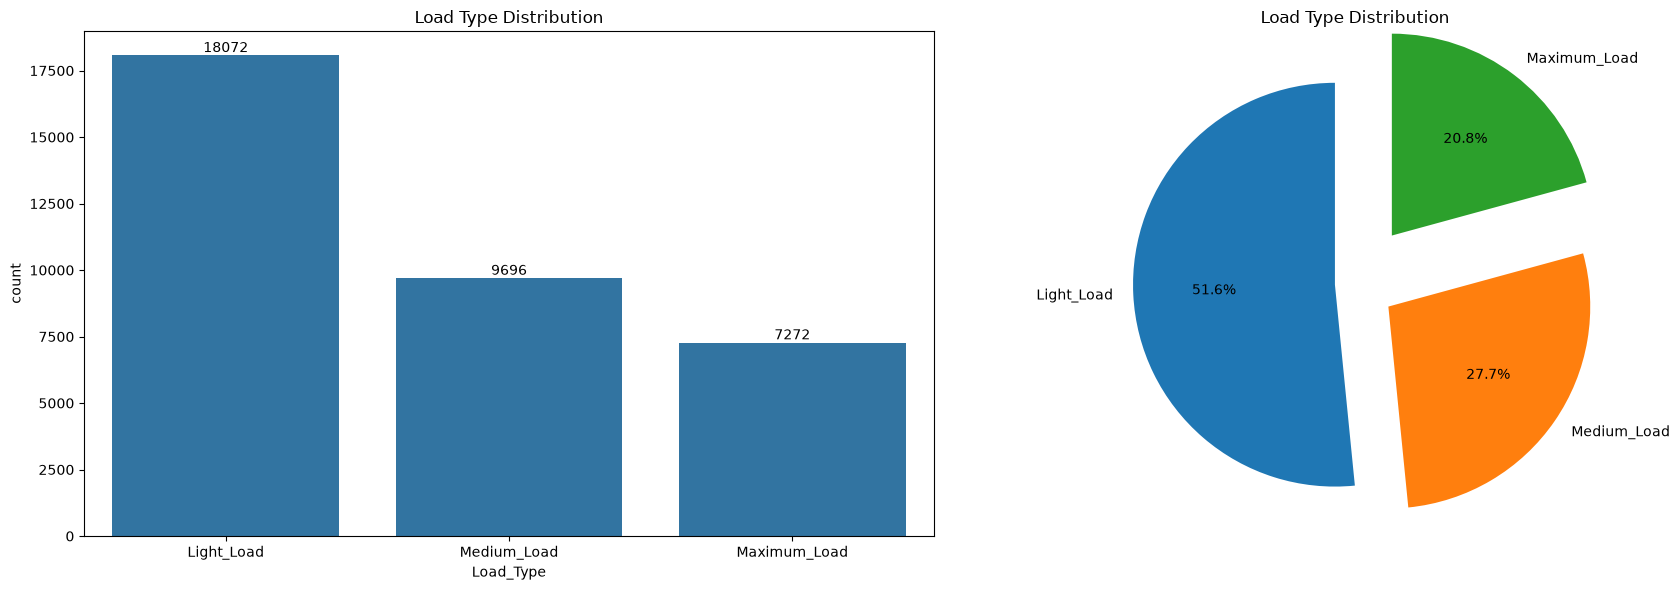

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
barplot = sns.countplot(x = preprocessed_df["Load_Type"], ax = ax[0])
for container in barplot.containers:
    ax[0].bar_label(container, fmt="%d")
ax[0].set_title("Load Type Distribution")

labels = preprocessed_df["Load_Type"].unique().tolist()
counts = preprocessed_df["Load_Type"].value_counts().reindex(labels)
explode = (0.1, 0.2, 0.3)

ax[1].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    explode = explode
)
ax[1].set_title("Load Type Distribution")
plt.tight_layout()
plt.show()

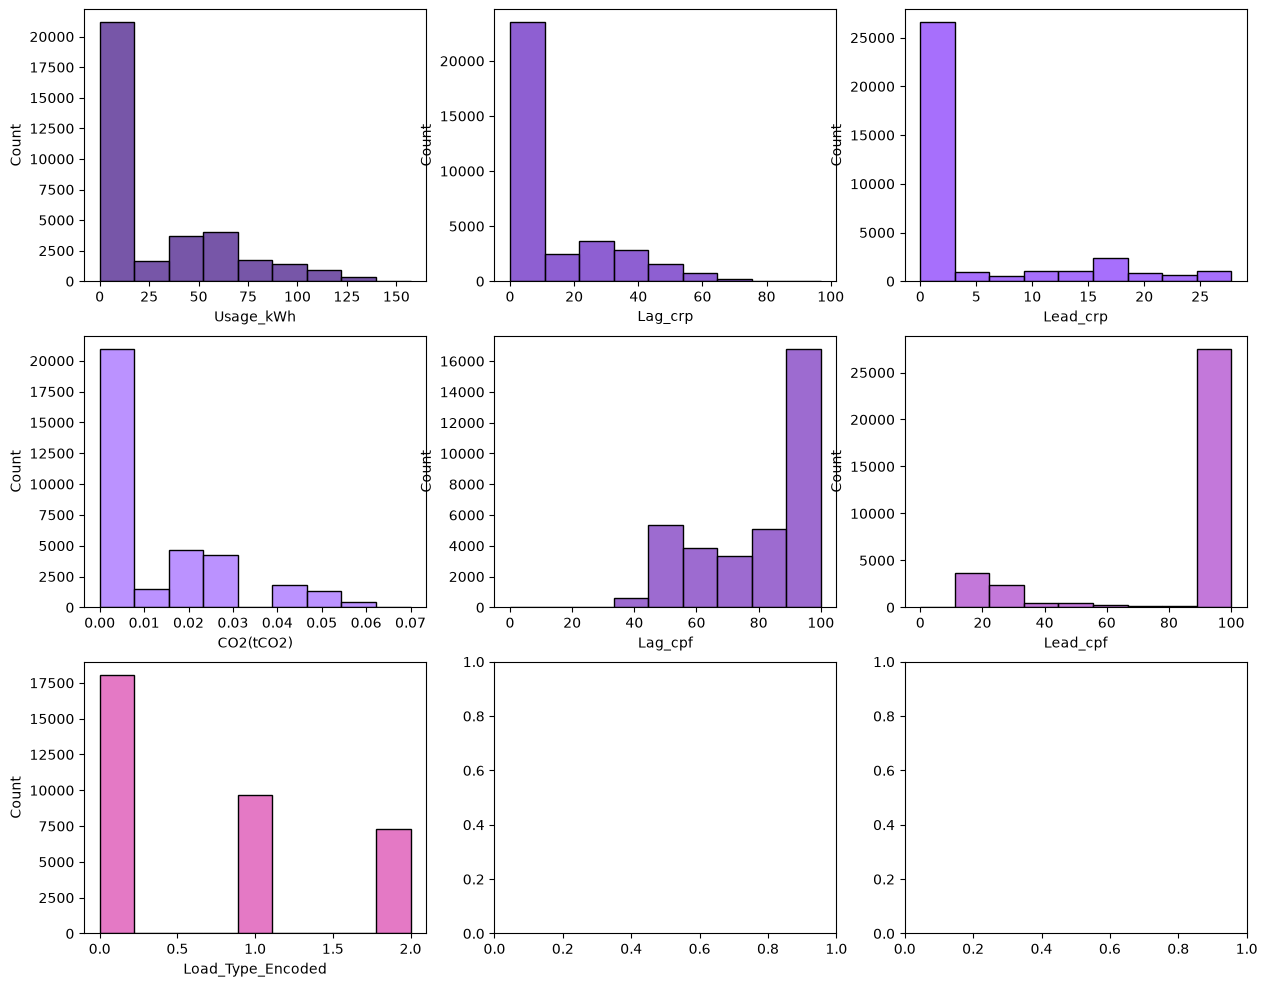

In [73]:
columns = ['Usage_kWh',
 'Lag_crp',
 'Lead_crp',
 'CO2(tCO2)',
 'Lag_cpf',
 'Lead_cpf',
 'Load_Type_Encoded']
colors = ['#491D8B', '#6929C4', '#8A3FFC', '#A56EFF',
          '#7D3AC1', '#AF4BCE', '#DB4CB2']

c = 3
rows = (len(columns) + c - 1) // c 
fig, ax = plt.subplots(rows, c, figsize=(5 * c, 4 * rows))

ax = np.array(ax).flatten()

if len(ax) == 1:
    ax = [ax]

for i, feature in enumerate(columns):
    sns.histplot(
        data=preprocessed_df,
        x=feature,
        bins=9,
        color=colors[i],
        ax=ax[i]
    )
plt.show()

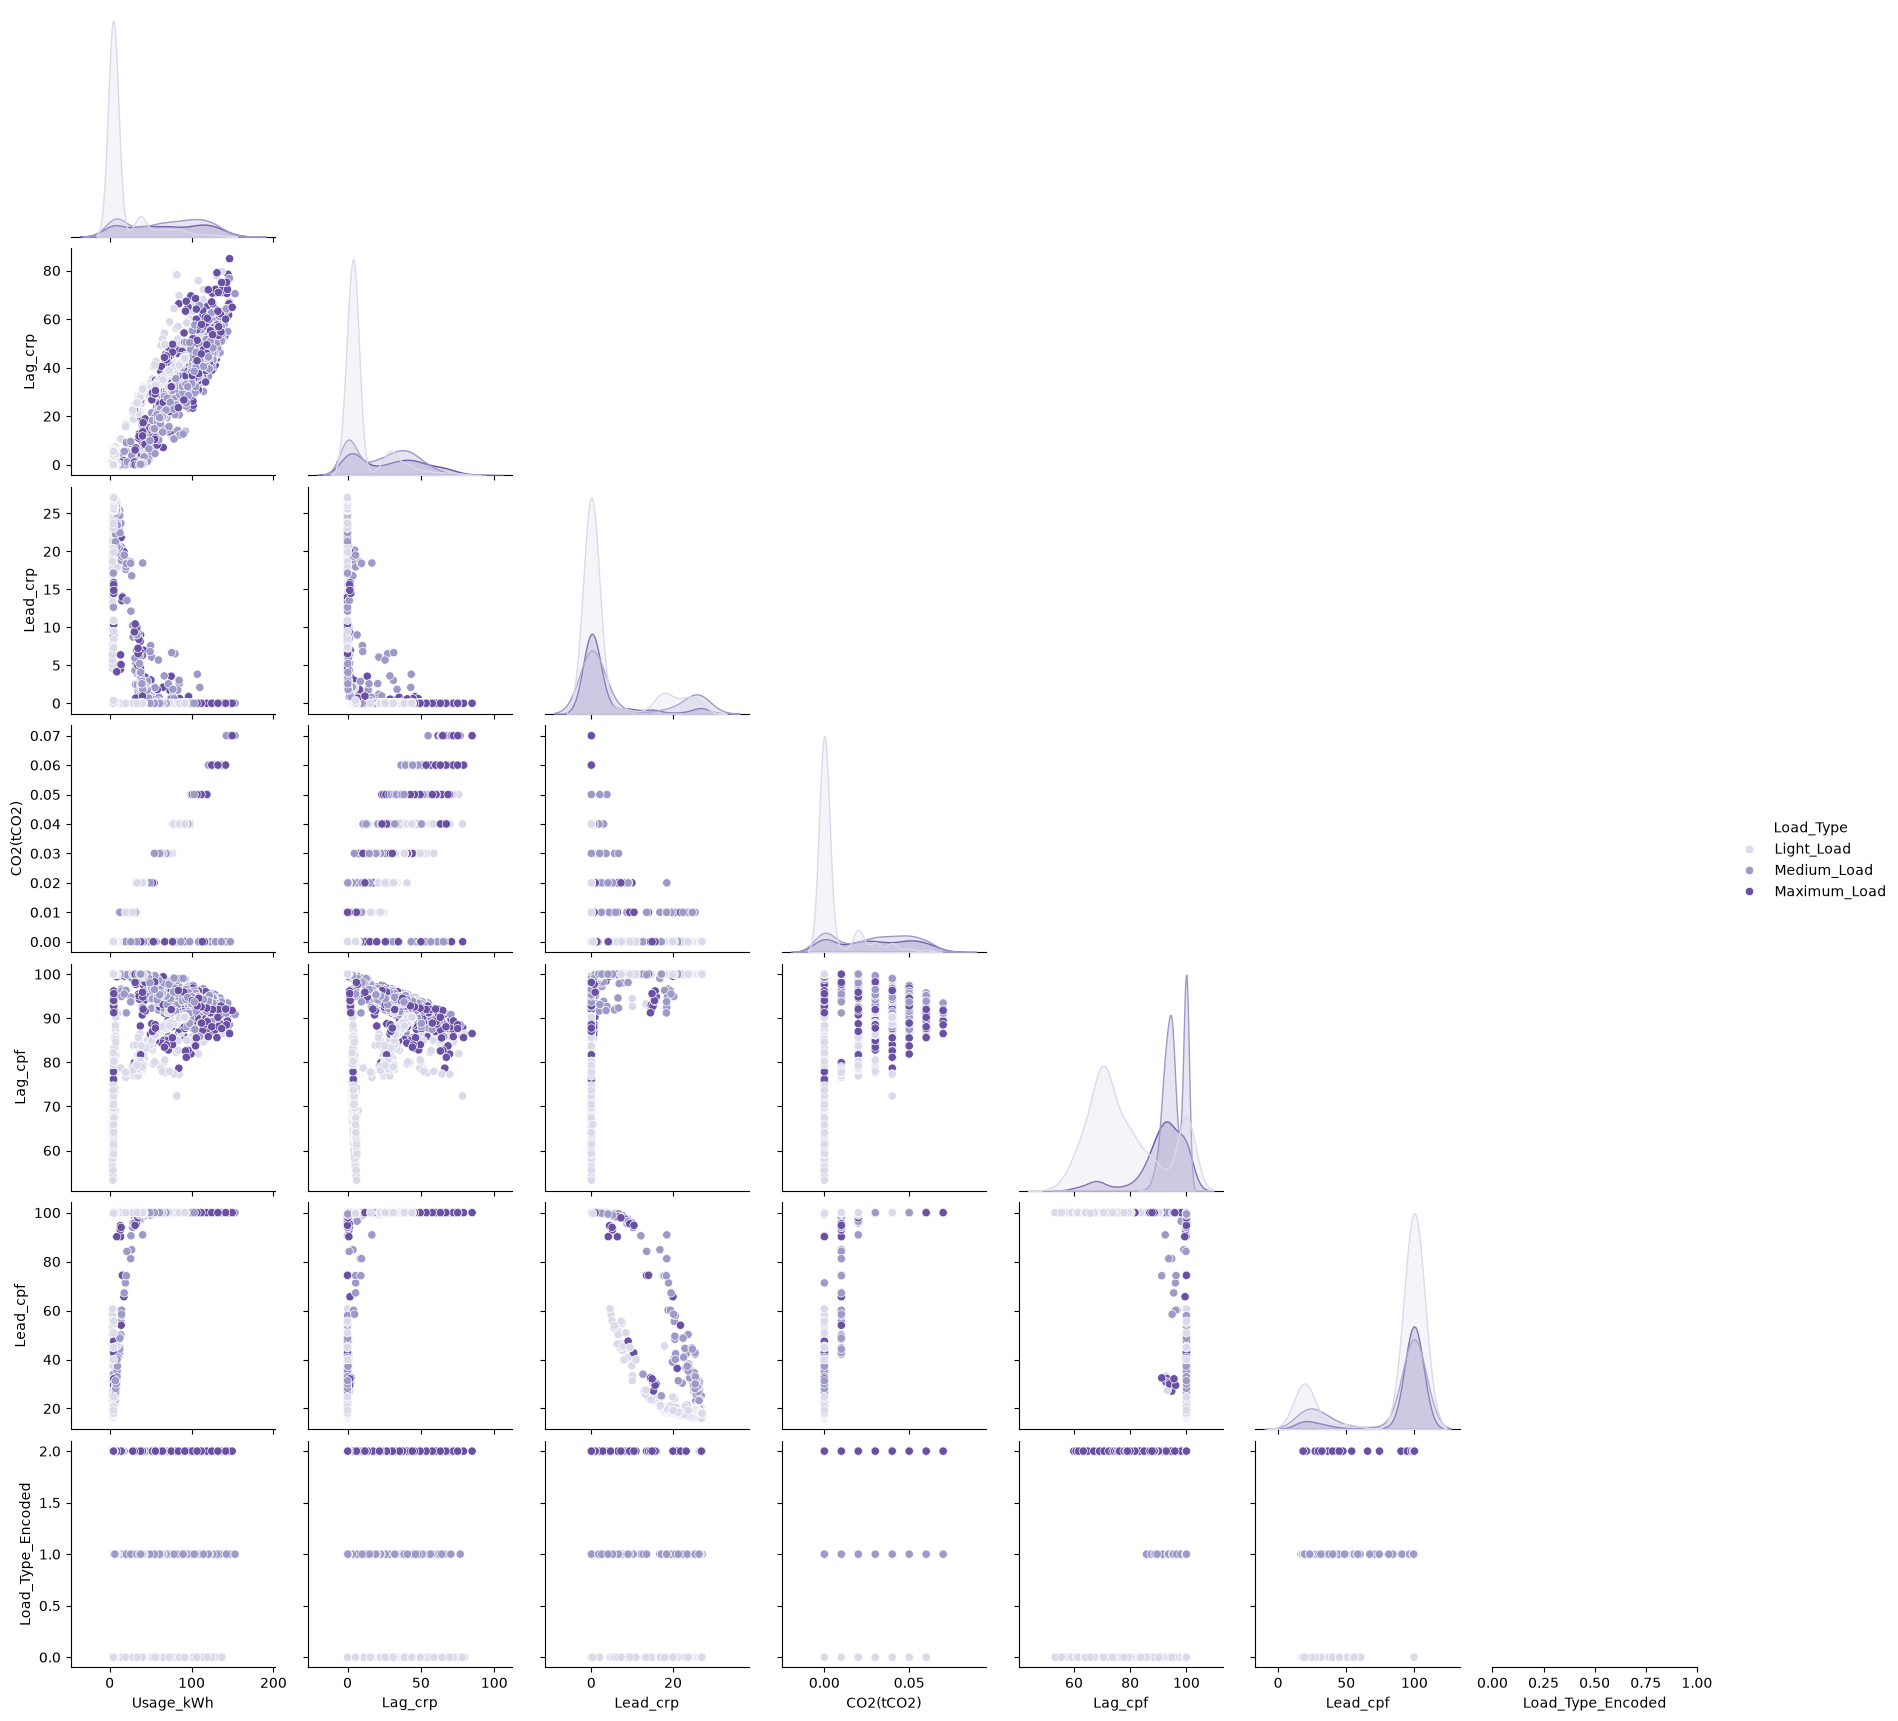

In [75]:
sns.pairplot(
    data = preprocessed_df[:2000],
    vars = columns,
    hue = "Load_Type",
    palette="Purples",
    corner = True
)

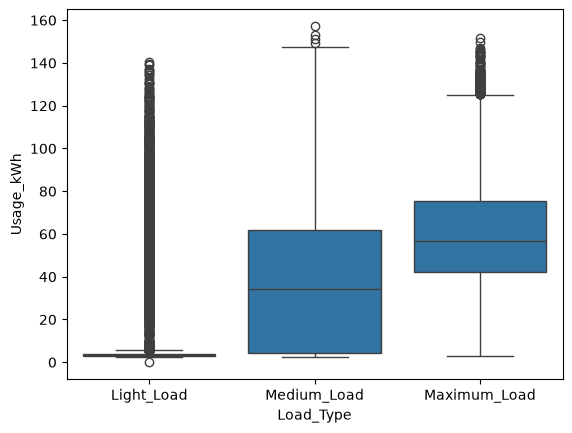

In [77]:
sns.boxplot(x = "Load_Type", y = "Usage_kWh", data = preprocessed_df)
plt.show()

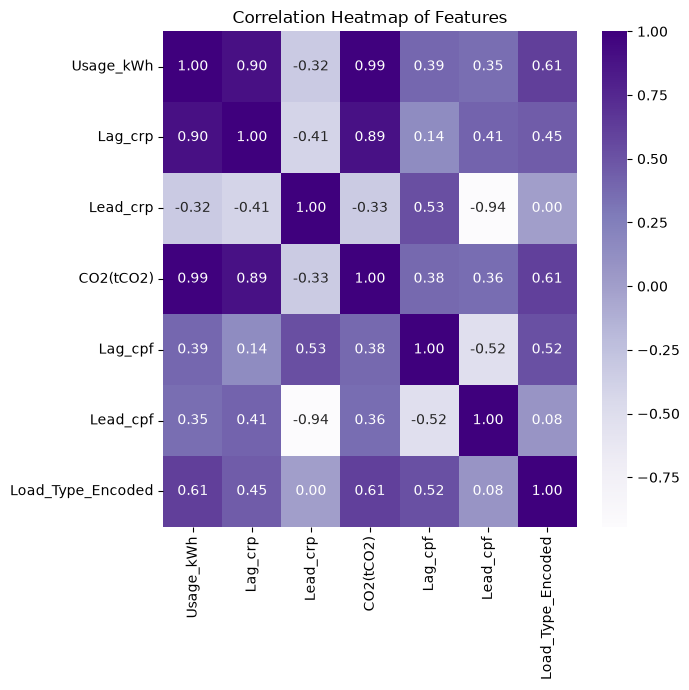

In [85]:
numerical_df = preprocessed_df[columns]

plt.figure(figsize = (7, 7))
sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap = "Purples",
    fmt='.2f'
)
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

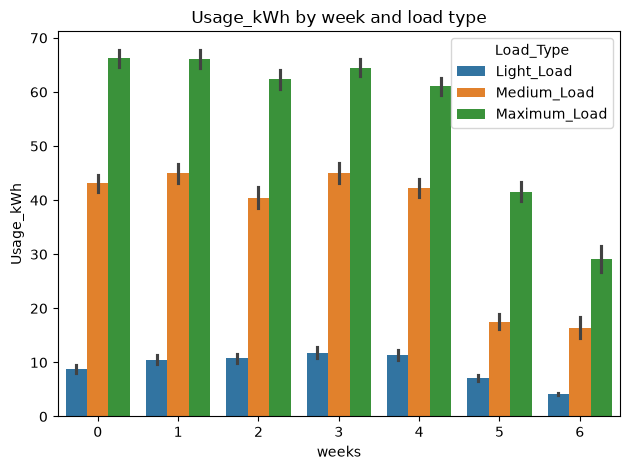

In [88]:
sns.barplot(
    data = preprocessed_df,
    x = "weeks",
    y = "Usage_kWh",
    hue = "Load_Type"
)
plt.title("Usage_kWh by week and load type")
plt.tight_layout()
plt.show()